# Visualize Example Solution: comp1

## imports

In [59]:
# Imports
import os
import re
import pandas as pd
import geopandas as gpd
import ast  # to safely parse string lists
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import matplotlib.pyplot as plt
from collections import Counter

import shutil
import numpy as np
import pickle
import networkx as nx

### load shapefile comp

In [66]:
# Load the GeoDataFrame for comp_1
shapefile_path = r"1_Preprocessed_Data\3_Stand_Components\3_merged_components\comp_10_stands.shp"
stands = gpd.read_file(shapefile_path)
print(f"Component loaded with {len(stands)} stands.")

Component loaded with 18 stands.


## load access needs for comp

In [67]:
ac_needs = pd.read_csv(r"1_Preprocessed_Data\2_Stands_Access_Requirements\mres_stands_access_needs.csv")

In [68]:
ID_UGs = stands["ID_UG"].tolist()
ID_UGs.sort()
ID_UGs

[821,
 822,
 823,
 851,
 852,
 853,
 854,
 1172,
 1181,
 1231,
 1241,
 1284,
 1285,
 1286,
 1399,
 1423,
 1424,
 1555]

In [79]:
# Filter the matrix for only those stands
filtered_acc = ac_needs[ac_needs["ID_UG"].isin(stands["ID_UG"])]
filtered_acc

,ID_UG,timber_1,timber_2,timber_3,timber_4,timber_5,wide_1,wide_2,wide_3,wide_4,wide_5
23,1423,1,1,1,1,1,0,0,0,0,0
48,851,1,0,0,1,1,0,0,0,0,0
53,821,0,1,1,0,0,0,0,0,0,0
54,822,0,1,0,1,0,0,0,0,0,0
57,852,1,1,1,1,1,0,0,0,0,0
58,853,1,0,0,0,0,0,0,0,0,0
198,1231,1,0,0,1,1,0,0,0,0,0
209,1284,1,1,1,1,1,0,0,0,0,0
242,1424,1,1,1,1,0,0,0,0,0,0
276,1555,0,0,0,0,0,0,0,0,1,1


### accessibility status in comp

In [80]:
inac = pd.read_csv(r"1_Preprocessed_Data\1_Stand_Accessibility\stands_inaccessible.csv")
ac = pd.read_csv(r"1_Preprocessed_Data\1_Stand_Accessibility\stands_accessible.csv")
t_ac = pd.read_csv(r"1_Preprocessed_Data\1_Stand_Accessibility\stands_timberroadonly.csv")

# Make sets for faster lookup
inac_set = set(inac['ID_UG'])
ac_set = set(ac['ID_UG'])
tac_set = set(t_ac['ID_UG'])

In [81]:
# Separate lists for inaccessible and accessible
inaccessible_ugs = [ug for ug in ID_UGs if ug in inac_set]
accessible_ugs = [ug for ug in ID_UGs if ug in ac_set]
timberroadonly_ugs = [ug for ug in ID_UGs if ug in tac_set]

print("Inaccessible ID_UGs:", inaccessible_ugs)
print("Accessible ID_UGs:", accessible_ugs)
print("Accessible via timberroad UGs:", timberroadonly_ugs)


Inaccessible ID_UGs: [821, 822, 851, 852, 853, 1231, 1284, 1423, 1424, 1555]
Accessible ID_UGs: [1172]
Accessible via timberroad UGs: [823, 854, 1181, 1241, 1285, 1286, 1399]


## load comp graph data from original graph creation process

### load arcs with attributes

In [8]:
# Path to the arcs_with_attributes CSV for comp_1
arcs_file = r"1_Preprocessed_Data\4_Road_Network_Graphs\comp_10\arcs_with_attributes.csv"

# Load the CSV
arcs_df = pd.read_csv(arcs_file)

# Convert the Source/Target columns to tuple coordinates
arcs_df['Source(x,y)'] = arcs_df['Source(x,y)'].apply(eval)
arcs_df['Target(x,y)'] = arcs_df['Target(x,y)'].apply(eval)

# Check loaded data
print(f"Loaded {len(arcs_df)} arcs with attributes.")
print(arcs_df.head())

Loaded 222 arcs with attributes.
                    Source(x,y)                   Target(x,y)  edgelength  \
0  (-15014.72408, 153167.90491)  (-15095.01908, 153300.52321)    0.184807   
1  (-15014.72408, 153167.90491)  (-15001.70948, 152924.85131)    0.245102   
2  (-15014.72408, 153167.90491)  (-15055.73748, 152930.22141)    0.284652   
3  (-15095.01908, 153300.52321)  (-15014.72408, 153167.90491)    0.184807   
4  (-15095.01908, 153300.52321)  (-14962.21548, 153358.86791)    0.150687   

   has_exit  has_source  Build5m  Maintain5m  Build10m  Maintain10m  Upgrade  \
0     False       False     1389         495      2082          495     1042   
1      True       False     1842         658      2763          658     1381   
2      True       False     1375         535      2062          535     1032   
3     False       False     1389         495      2082          495     1042   
4     False       False     1133         404      1699          404      849   

   slope               

### load source and exit nodes

In [9]:
source_nodes_file = r"1_Preprocessed_Data\4_Road_Network_Graphs\comp_10\source_nodes.csv"
exit_nodes_file   = r"1_Preprocessed_Data\4_Road_Network_Graphs\comp_10\exit_nodes.csv"

# --- Load the source/exit node coordinates ---
source_df = pd.read_csv(source_nodes_file)
exit_df   = pd.read_csv(exit_nodes_file)

# Convert to sets of tuples for quick lookup
source_nodes = set(zip(source_df['x'], source_df['y']))
exit_nodes   = set(zip(exit_df['x'], exit_df['y']))

print(f"Loaded {len(source_nodes)} source nodes and {len(exit_nodes)} exit nodes.")


Loaded 10 source nodes and 16 exit nodes.


## recreate graph from original graph data

In [10]:
# --- Extract unique vertices from arcs CSV ---
vertices = set()
for u, v in zip(arcs_df['Source(x,y)'], arcs_df['Target(x,y)']):
    vertices.add(u)
    vertices.add(v)
vertices = list(vertices)
print(f"Found {len(vertices)} unique vertices.")

# --- Create node_to_stands mapping if needed (empty for now) ---
node_to_stands = {v: [] for v in vertices}

# --- Create undirected NetworkX graph with source/exit info ---
G = nx.Graph()

# Add nodes with source/exit flags
for node in vertices:
    is_source = node in source_nodes
    is_exit   = node in exit_nodes
    G.add_node(node, is_source=is_source, is_exit=is_exit, stands=node_to_stands.get(node, []))

# Add edges with all attributes from arcs_df
for idx, row in arcs_df.iterrows():
    u = row['Source(x,y)']
    v = row['Target(x,y)']
    attr = row.drop(['Source(x,y)', 'Target(x,y)']).to_dict()
    G.add_edge(u, v, **attr)

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Found 58 unique vertices.
Graph created with 58 nodes and 111 edges.


In [11]:
for node, data in G.nodes(data=True):
    print(f"Node: {node}, attributes: {data}")

Node: (-15419.81558, 153317.89911), attributes: {'is_source': False, 'is_exit': False, 'stands': []}
Node: (-16017.60378, 154010.95271), attributes: {'is_source': False, 'is_exit': False, 'stands': []}
Node: (-14835.89608, 153934.05631), attributes: {'is_source': False, 'is_exit': False, 'stands': []}
Node: (-14784.89698, 153967.79781), attributes: {'is_source': False, 'is_exit': True, 'stands': []}
Node: (-14857.24072, 153996.39466), attributes: {'is_source': False, 'is_exit': True, 'stands': []}
Node: (-16304.48518, 153386.81631), attributes: {'is_source': False, 'is_exit': False, 'stands': []}
Node: (-15565.90848, 154228.96621), attributes: {'is_source': False, 'is_exit': False, 'stands': []}
Node: (-15812.90547, 153683.01471), attributes: {'is_source': True, 'is_exit': False, 'stands': []}
Node: (-15765.33368, 153918.74811), attributes: {'is_source': False, 'is_exit': False, 'stands': []}
Node: (-14888.28368, 153768.95591), attributes: {'is_source': False, 'is_exit': True, 'stands'

### plot

In [12]:
# --- Prepare sets for accessible/inaccessible stands ---
ac_set = set(ac['ID_UG'])
inac_set = set(inac['ID_UG'])

## load solution data

In [84]:
sol_path = r"2_Model_and_Solution\mres\comp_10\solution_full.csv"
sol_df = pd.read_csv(sol_path)
sol_df

,variable,value,node_type_info,action,road_type,edge,period
0,C_node1node3_timber_t0,0.0,node1transit_node3transit,C,timber,node1node3,0.0
1,C_node1node3_timber_t1,0.0,node1transit_node3transit,C,timber,node1node3,1.0
2,C_node1node3_timber_t2,0.0,node1transit_node3transit,C,timber,node1node3,2.0
3,C_node1node3_timber_t3,0.0,node1transit_node3transit,C,timber,node1node3,3.0
4,C_node1node3_timber_t4,-0.0,node1transit_node3transit,C,timber,node1node3,4.0
...,...,...,...,...,...,...,...
5545,flow_wide_node47node48_t1,0.0,node47exit_node48exit,flow,wide,node47node48,1.0
5546,flow_wide_node47node48_t2,0.0,node47exit_node48exit,flow,wide,node47node48,2.0
5547,flow_wide_node47node48_t3,0.0,node47exit_node48exit,flow,wide,node47node48,3.0
5548,flow_wide_node47node48_t4,0.0,node47exit_node48exit,flow,wide,node47node48,4.0


## recreate node mapping

In [15]:
# load nodes for component 1 and rebuild the same node mapping as in CPLEX implementation Workflow notebook

file_path = r"1_Preprocessed_Data\4_Road_Network_Graphs\comp_10\4withsources_nodes.csv"
nodes_df = pd.read_csv(file_path)

# filter nodes
V_source = nodes_df[nodes_df["is_source"] == True]
V_exit = nodes_df[nodes_df["is_exit"] == True]

# all node coordinates
V = list(zip(nodes_df["x"], nodes_df["y"]))

# forward mapping: node name → coordinates
node_ID_mapping = {f"node{i + 1}": V[i] for i in range(len(V))}

# reverse mapping: coordinates → node name
reversed_node_ID_mapping = {v: k for k, v in node_ID_mapping.items()}

# all node IDs
V_IDs = [reversed_node_ID_mapping[v] for v in V]

# source and exit node IDs
V_source_IDs = [reversed_node_ID_mapping[v] for v in zip(V_source["x"], V_source["y"])]
V_exit_IDs = [reversed_node_ID_mapping[v] for v in zip(V_exit["x"], V_exit["y"])]

## visualize solution in the graph

### helper function

In [127]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from matplotlib.lines import Line2D
import re

def plot_stands_graph(G, stands, sol_filtered, node_ID_mapping, title="Graph Plot with Stands", figsize=(10, 10)):
    """
    Plots a NetworkX graph G over a GeoDataFrame of stands, highlighting selected edges from sol_filtered.

    Parameters:
        G (nx.Graph): The NetworkX graph to plot.
        stands (GeoDataFrame): GeoDataFrame containing stand polygons with 'ID_UG' and optionally 'road_acces'.
        sol_filtered (DataFrame): DataFrame containing a column 'edge' with strings like 'node1node4' for edges to highlight.
        node_ID_mapping (dict): Mapping from node ID string to coordinate tuple (used for highlighted edges).
        title (str): Title of the plot.
        figsize (tuple): Figure size.
    """

    fig, ax = plt.subplots(figsize=figsize)

    # --- Function to color stands ---
    def get_color(row):
        access = str(row.get('road_acces', '')).lower()
        if access == 'none':
            return (1.0, 0.8, 0.4, 0.3)
        else:
            return (0.5, 1.0, 0.5, 0.3)

    stands.plot(ax=ax, color=stands.apply(get_color, axis=1), edgecolor='none')

    # Annotate ID_UG
    for x, y, label in zip(stands.geometry.representative_point().x,
                           stands.geometry.representative_point().y,
                           stands['ID_UG']):
        ax.text(x+3, y+3, label, fontsize=8, color='black')

    # --- Node colors ---
    node_colors = []
    for node in G.nodes():
        if G.nodes[node].get('is_source', False):
            node_colors.append('orange')
        elif G.nodes[node].get('is_exit', False):
            node_colors.append('blue')
        else:
            node_colors.append('grey')

    # Prepare edge colors
    edgecolors = [
        'orange' if G[u][v].get('has_source') else 'grey'  # stronger orange-yellow for source edges
        for u, v in G.edges()
    ]

    # --- Highlighted edges with color based on type ---
    highlight_edges = []
    highlight_colors = []
    highlight_widths = []

    pattern = re.compile(r'node(\d+)node(\d+)')  # captures any length numbers

    for edge_str in sol_filtered["edge"]:
        match = pattern.fullmatch(edge_str)
        if match:
            u_id = 'node' + match.group(1)
            v_id = 'node' + match.group(2)
            if u_id in node_ID_mapping and v_id in node_ID_mapping:
                u_coord = node_ID_mapping[u_id]
                v_coord = node_ID_mapping[v_id]
                highlight_edges.append((u_coord, v_coord))

                # Determine edge type
                edge_type = sol_filtered.loc[sol_filtered["edge"] == edge_str, "road_type"].values[0].lower()
                if edge_type == 'timber':
                    highlight_colors.append('black')
                    highlight_widths.append(2)
                elif edge_type == 'wide':
                    highlight_colors.append('red')
                    highlight_widths.append(4)
                else:
                    highlight_colors.append('black')  # default color
                    highlight_widths.append(1)

    # --- Draw all edges faint ---
    nx.draw_networkx_edges(G,
                           pos={node: node for node in G.nodes()},
                           edge_color=edgecolors,
                           width=1,
                           alpha=.3,
                           ax=ax)

    # --- Draw highlighted edges with type colors ---
    for (u, v), color, width in zip(highlight_edges, highlight_colors, highlight_widths):
        ax.plot([u[0], v[0]], [u[1], v[1]], color=color, linewidth=width)

    # --- Draw nodes ---
    nx.draw_networkx_nodes(G,
                           pos={node: node for node in G.nodes()},
                           node_color=node_colors,
                           node_size=50,
                           ax=ax)

    # --- Graph stats ---
    degree_counts = Counter(dict(G.degree()).values())
    total_edge_length = sum(G[u][v].get('edgelength', 0) for u, v in G.edges())
    exit_nodes_count = sum(1 for n in G.nodes() if G.nodes[n].get('is_exit', False))
    source_nodes_count = sum(1 for n in G.nodes() if G.nodes[n].get('is_source', False))

    plt.title(f"{title}")

    # --- Legend ---
    graph_legend = [
        Line2D([0], [0], color='grey', lw=1, label='Edge'),
        Line2D([0], [0], marker='o', color='grey', label='Node', alpha=.2,
               markerfacecolor='grey', markersize=8, linestyle='None'),
        Line2D([0], [0], marker='o', color='blue', label='Exit Node',
               markerfacecolor='blue', markersize=8, linestyle='None'),
        Line2D([0], [0], marker='o', color='orange', label='Source Node',
               markerfacecolor='orange', markersize=8, linestyle='None'),
        Line2D([0], [0], color='black', lw=2, label='Selected edge timber width'),
        Line2D([0], [0], color='red', lw=4, label='Selected edge wide width')
    ]

    plt.legend(handles=graph_legend, loc='upper left')
    ax.set_axis_off()


### AllinOne Plot

In [115]:
# Filter for value=1
sol_filtered = sol_df[
    (sol_df.value >= 1) &
    (~sol_df['node_type_info'].str.contains("source"))
]
print(f"Filtered to {len(sol_filtered)} selected edges")
sol_filtered.head(2)

Filtered to 134 selected edges


,variable,value,node_type_info,action,road_type,edge,period
37,C_node2node39_timber_t1,1.0,node2transit_node39transit,C,timber,node2node39,1.0
49,C_node2node13_timber_t1,1.0,node2transit_node13transit,C,timber,node2node13,1.0


C:\Users\johan\AppData\Local\Temp\ipykernel_6000\1453602759.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G,


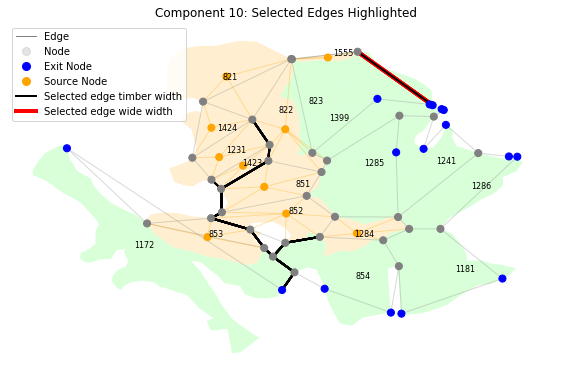

In [128]:
plot_stands_graph(
    G=G,
    stands=stands,
    sol_filtered=sol_filtered,
    node_ID_mapping=node_ID_mapping,
    title="Component 10: Selected Edges Highlighted"
)
plt.show()


### plot per period

C:\Users\johan\AppData\Local\Temp\ipykernel_6000\1560728982.py:53: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G,
C:\Users\johan\AppData\Local\Temp\ipykernel_6000\1560728982.py:53: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G,
C:\Users\johan\AppData\Local\Temp\ipykernel_6000\1560728982.py:53: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G,
C:\Users\johan\AppData\Local\Temp\ipykernel_6000\1560728982.py:53: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G,
C:\Users\johan\AppData\Local\Temp\ipykernel_6000\1560728982.py:53: DeprecationWarning: `alltrue` is deprecated as of NumPy 1

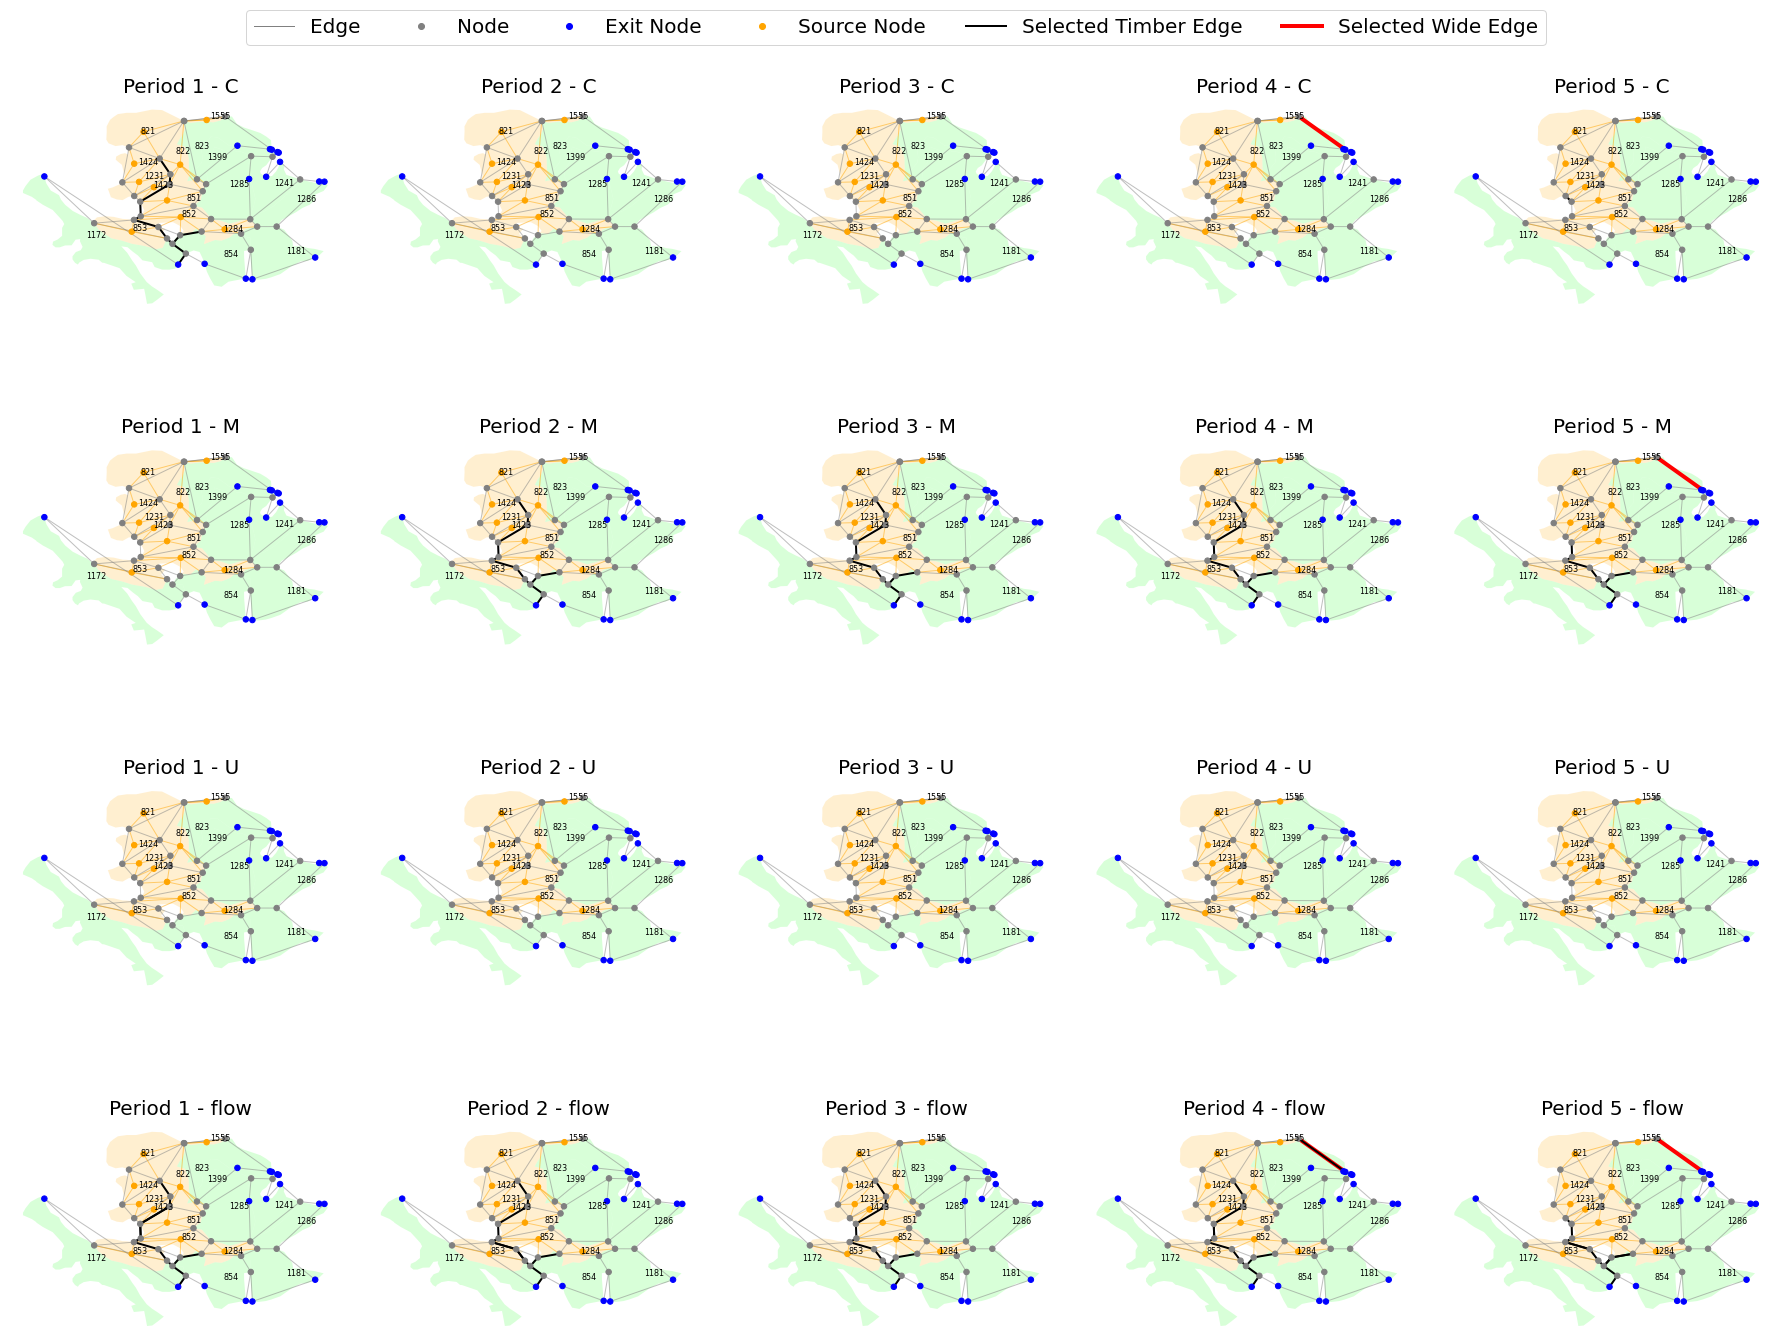

In [129]:
# --- Automatically get unique periods and actions from sol_df ---
periods = [1,2,3,4,5]
actions = sorted(sol_df['action'].unique())

fig, axes = plt.subplots(len(actions), len(periods), figsize=(25, 20), sharex=True, sharey=True)

# Regex pattern for edges like node300node3
edge_pattern = re.compile(r'(node\d+)(node\d+)')

# --- Loop over actions and periods ---
for i, action in enumerate(actions):
    for j, period in enumerate(periods):
        ax = axes[i, j]

        # Filter dataframe for current period & action
        df_subset = sol_df[(sol_df['period'] == period) &
                           (sol_df['action'] == action) &
                           (sol_df['value'] >= 1) &
                           (~sol_df['node_type_info'].str.contains("source"))]

        # --- Plot stands ---
        def get_color(row):
            access = str(row.get('road_acces', '')).lower()
            if access == 'none':
                return (1.0, 0.8, 0.4, 0.3)
            else:
                return (0.5, 1.0, 0.5, 0.3)

        stands.plot(ax=ax, color=stands.apply(get_color, axis=1), edgecolor='none')

        # Annotate ID_UG
        for x, y, label in zip(stands.geometry.representative_point().x,
                               stands.geometry.representative_point().y,
                               stands['ID_UG']):
            ax.text(x+3, y+3, label, fontsize=8, color='black')

        # --- Node colors ---
        node_colors = []
        for node in G.nodes():
            if G.nodes[node].get('is_source', False):
                node_colors.append('orange')
            elif G.nodes[node].get('is_exit', False):
                node_colors.append('blue')
            else:
                node_colors.append('grey')

        # --- Draw all edges faint ---
        # Prepare edge colors
        edgecolors = [
            'orange' if G[u][v].get('has_source') else 'grey'  # stronger orange-yellow for source edges
            for u, v in G.edges()
        ]
        nx.draw_networkx_edges(G,
                               pos={node: node for node in G.nodes()},
                               edge_color=edgecolors,
                               width=1,
                               alpha=.5,
                               ax=ax)

        # --- Highlight edges with color by road_type using regex ---
        for _, row in df_subset.iterrows():
            edge_str = row["edge"]
            roadtype = str(row.get("road_type", "")).lower()

            match = edge_pattern.fullmatch(edge_str)
            if match:
                u_id, v_id = match.group(1), match.group(2)

                if u_id in node_ID_mapping and v_id in node_ID_mapping:
                    u_coord = node_ID_mapping[u_id]
                    v_coord = node_ID_mapping[v_id]

                    # Set edge color and width based on road_type
                    if roadtype == "wide":
                        color = "red"
                        width = 4
                    else:  # timber or anything else
                        color = "black"
                        width = 2

                    ax.plot([u_coord[0], v_coord[0]],
                            [u_coord[1], v_coord[1]],
                            color=color,
                            linewidth=width)

        # --- Draw nodes ---
        nx.draw_networkx_nodes(G,
                               pos={node: node for node in G.nodes()},
                               node_color=node_colors,
                               node_size=30,
                               ax=ax)

        # --- Remove axis and add title ---
        ax.set_axis_off()
        ax.set_title(f"Period {period} - {action}", fontsize=20)

# --- Add unified legend ---
graph_legend = [
    Line2D([0], [0], color='grey', lw=1, label='Edge'),
    Line2D([0], [0], marker='o', color='grey', label='Node',
           markerfacecolor='grey', markersize=6, linestyle='None'),
    Line2D([0], [0], marker='o', color='blue', label='Exit Node',
           markerfacecolor='blue', markersize=6, linestyle='None'),
    Line2D([0], [0], marker='o', color='orange', label='Source Node',
           markerfacecolor='orange', markersize=6, linestyle='None'),
    Line2D([0], [0], color='black', lw=2, label='Selected Timber Edge'),
    Line2D([0], [0], color='red', lw=4, label='Selected Wide Edge')
]

fig.legend(handles=graph_legend, loc='upper center', ncol=6, fontsize=20)
plt.tight_layout()
plt.show()